# Cross-task aggregate: reassigned neurons

Compare **reassigned neuron** counts (dead at some checkpoint, then `assigned` later) across experiments and optimizers. Data matches the *Reassigned neurons* section in `network_analysis.ipynb` / `network_analysis_classic_task.ipynb`.

In [1]:
import sys
from pathlib import Path

_PROJECT_ROOT = Path(".").resolve()
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from visualize_webapp.app import scan_results
from visualize_webapp.notebook.plot_cross_task import (
    load_reactivated_summaries_for_experiment_runs,
    load_summaries_for_experiment_runs,
    optimizer_ids_for_experiment_runs,
    plot_reactivated_neuron_counts_grouped,
    plot_reassigned_neuron_counts_grouped,
)

## Configuration


In [ ]:
MODEL_ID = "dnn_5x64"
EXPERIMENT_RUNS = {
    "digit_ordered_0_1_75_25_tr100":"0d4f4a",
	"pretrain_0_mislabel1_1_K1000_tr100":"4a7338",
	"pretrainK1000_tr100_then_0":"6c35d5",
	"pretrain_relabelC_0_1_2_K1000_tr100":"6cef7f"
}
bar_width = 0.1 * len(EXPERIMENT_RUNS)

In [3]:
tree_all = scan_results()
for eid in EXPERIMENT_RUNS:
    models = tree_all.get(eid, {})
    for mid, runs in sorted(models.items()):
        for rid, oids in sorted(runs.items()):
            for oid in oids:
                mark = " *" if eid in EXPERIMENT_RUNS and rid == EXPERIMENT_RUNS[eid] else ""
                print(f"  experiment={eid!r}  model={mid!r}  run={rid!r}  optimizer={oid!r}{mark}")

  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='sgd_lr0.01' *
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='adagrad_lr0.01' *
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='adam_lr0.01' *
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='pure_shampoo_lr0.01' *
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='grafted_shampoo_lr0.01' *
  experiment='pretrain_0_mislabel1_1_K1000_tr100'  model='dnn_5x64'  run='4a7338'  optimizer='sgd_lr0.01' *
  experiment='pretrain_0_mislabel1_1_K1000_tr100'  model='dnn_5x64'  run='4a7338'  optimizer='adagrad_lr0.01' *
  experiment='pretrain_0_mislabel1_1_K1000_tr100'  model='dnn_5x64'  run='4a7338'  optimizer='adam_lr0.01' *
  experiment='pretrain_0_mislabel1_1_K1000_tr100'  model='dnn_5x64'  run='4a7338'  optimizer='pure_shampoo_lr0.01' *
  experiment=

## Reassigned summary (MultiIndex)

Rows are indexed by `(experiment_id, optimizer_id)`; columns match `df_reassigned_summary` in the network analysis notebooks.

**Note:** Optimizers with **zero** reassigned neurons do not appear in `df_multi` at all (empty summaries add no rows when concatenated). Use `optimizer_ids_for_experiment_runs` for the full list from discovery; pass it as `optimizer_order` to the grouped bar plots so every optimizer gets a bar (height 0 when missing).

In [4]:
tree = scan_results()
OPTIMIZER_IDS = optimizer_ids_for_experiment_runs(tree, EXPERIMENT_RUNS, MODEL_ID)
df_multi = load_summaries_for_experiment_runs(tree, EXPERIMENT_RUNS, MODEL_ID)
print(df_multi.shape)
display(df_multi.head(20))

(1120, 6)


compact               neuron_id  \
experiment_id                 optimizer_id                                     
digit_ordered_0_1_75_25_tr100 sgd_lr0.01        h6:1   dnn|hidden.6|neuron|1   
                              sgd_lr0.01       h6:13  dnn|hidden.6|neuron|13   
                              sgd_lr0.01       h6:55  dnn|hidden.6|neuron|55   
                              sgd_lr0.01       h6:10  dnn|hidden.6|neuron|10   
                              sgd_lr0.01       h8:25  dnn|hidden.8|neuron|25   
                              sgd_lr0.01       h8:35  dnn|hidden.8|neuron|35   
                              sgd_lr0.01        h8:2   dnn|hidden.8|neuron|2   
                              sgd_lr0.01       h8:20  dnn|hidden.8|neuron|20   
                              sgd_lr0.01       h8:52  dnn|hidden.8|neuron|52   
                              sgd_lr0.01       h8:16  dnn|hidden.8|neuron|16   
                              adagrad_lr0.01    h0:6   dnn|hidden.0|neuron|6   
                              adagrad_lr0.01   h2:45  dnn|hidden.2|neuron|45   
                              adagrad_lr0.01   h2:21  dnn|hidden.2|neuron|21   
                              adagrad_lr0.01   h2:22  dnn|hidden.2|neuron|22   
                              adagrad_lr0.01   h2:43  dnn|hidden.2|neuron|43   
                              adagrad_lr0.01   h2:55  dnn|hidden.2|neuron|55   
                              adagrad_lr0.01   h2:50  dnn|hidden.2|neuron|50   
                              adagrad_lr0.01   h2:38  dnn|hidden.2|neuron|38   
                              adagrad_lr0.01   h2:61  dnn|hidden.2|neuron|61   
                              adagrad_lr0.01   h2:16  dnn|hidden.2|neuron|16   

                                             layer_name  \
experiment_id                 optimizer_id                
digit_ordered_0_1_75_25_tr100 sgd_lr0.01       hidden.6   
                              sgd_lr0.01       hidden.6   
                              sgd_lr0.01       hidden.6   
                              sgd_lr0.01       hidden.6   
                              sgd_lr0.01       hidden.8   
                              sgd_lr0.01       hidden.8   
                              sgd_lr0.01       hidden.8   
                              sgd_lr0.01       hidden.8   
                              sgd_lr0.01       hidden.8   
                              sgd_lr0.01       hidden.8   
                              adagrad_lr0.01   hidden.0   
                              adagrad_lr0.01   hidden.2   
                              adagrad_lr0.01   hidden.2   
                              adagrad_lr0.01   hidden.2   
                              adagrad_lr0.01   hidden.2   
                              adagrad_lr0.01   hidden.2   
                              adagrad_lr0.01   hidden.2   
                              adagrad_lr0.01   hidden.2   
                              adagrad_lr0.01   hidden.2   
                              adagrad_lr0.01   hidden.2   

                                              first_reassign_checkpoint  \
experiment_id                 optimizer_id                                
digit_ordered_0_1_75_25_tr100 sgd_lr0.01                            305   
                              sgd_lr0.01                            305   
                              sgd_lr0.01                            305   
                              sgd_lr0.01                            306   
                              sgd_lr0.01                            106   
                              sgd_lr0.01                            204   
                              sgd_lr0.01                            305   
                              sgd_lr0.01                            305   
                              sgd_lr0.01                            305   
                              sgd_lr0.01                            310   
                              adagrad_lr0.01                        134   
          

In [5]:
print("From discovery (all optimizers for selected runs):", OPTIMIZER_IDS)
print("In df_multi index only:", df_multi.index.unique("optimizer_id").tolist())

From discovery (all optimizers for selected runs): ['adagrad_lr0.01', 'adam_lr0.01', 'grafted_shampoo_lr0.01', 'pure_shampoo_lr0.01', 'sgd_lr0.01']
In df_multi index only: ['sgd_lr0.01', 'adagrad_lr0.01', 'adam_lr0.01', 'pure_shampoo_lr0.01', 'grafted_shampoo_lr0.01']


## Plot: reassigned neuron counts

X-axis = optimizer; grouped bars = one bar per experiment; Y = number of reassigned neurons (unique neurons dead then later assigned).

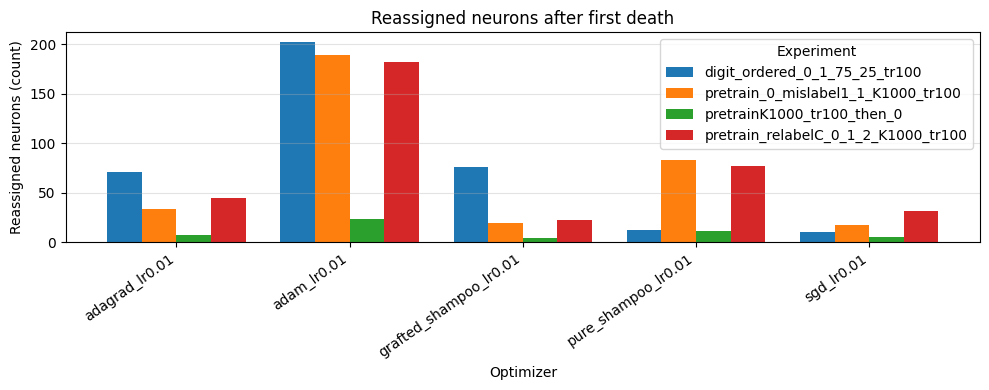

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)
plot_reassigned_neuron_counts_grouped(
    df_multi,
    ax=ax,
    experiment_order=list(EXPERIMENT_RUNS.keys()),
    optimizer_order=OPTIMIZER_IDS,
	bar_width = bar_width
)
fig.tight_layout()
plt.show()

## Re-activated summary

One row per neuron with at least one dead→alive step between neighbouring checkpoints (hidden layers). Index: `(experiment_id, optimizer_id)`.

In [7]:
df_reactivated_multi = load_reactivated_summaries_for_experiment_runs(
    tree, EXPERIMENT_RUNS, MODEL_ID
)
print(df_reactivated_multi.shape)
display(df_reactivated_multi.head(20))

(1794, 4)


compact               neuron_id  \
experiment_id                 optimizer_id                                   
digit_ordered_0_1_75_25_tr100 sgd_lr0.01     h2:61  dnn|hidden.2|neuron|61   
                              sgd_lr0.01     h2:31  dnn|hidden.2|neuron|31   
                              sgd_lr0.01      h2:0   dnn|hidden.2|neuron|0   
                              sgd_lr0.01     h2:23  dnn|hidden.2|neuron|23   
                              sgd_lr0.01     h2:52  dnn|hidden.2|neuron|52   
                              sgd_lr0.01      h2:9   dnn|hidden.2|neuron|9   
                              sgd_lr0.01     h4:31  dnn|hidden.4|neuron|31   
                              sgd_lr0.01     h4:52  dnn|hidden.4|neuron|52   
                              sgd_lr0.01     h4:17  dnn|hidden.4|neuron|17   
                              sgd_lr0.01     h4:25  dnn|hidden.4|neuron|25   
                              sgd_lr0.01     h4:60  dnn|hidden.4|neuron|60   
                              sgd_lr0.01     h6:12  dnn|hidden.6|neuron|12   
                              sgd_lr0.01      h6:6   dnn|hidden.6|neuron|6   
                              sgd_lr0.01      h6:2   dnn|hidden.6|neuron|2   
                              sgd_lr0.01     h6:26  dnn|hidden.6|neuron|26   
                              sgd_lr0.01     h6:27  dnn|hidden.6|neuron|27   
                              sgd_lr0.01     h6:37  dnn|hidden.6|neuron|37   
                              sgd_lr0.01     h6:55  dnn|hidden.6|neuron|55   
                              sgd_lr0.01     h6:16  dnn|hidden.6|neuron|16   
                              sgd_lr0.01     h6:39  dnn|hidden.6|neuron|39   

                                           layer_name  \
experiment_id                 optimizer_id              
digit_ordered_0_1_75_25_tr100 sgd_lr0.01     hidden.2   
                              sgd_lr0.01     hidden.2   
                              sgd_lr0.01     hidden.2   
                              sgd_lr0.01     hidden.2   
                              sgd_lr0.01     hidden.2   
                              sgd_lr0.01     hidden.2   
                              sgd_lr0.01     hidden.4   
                              sgd_lr0.01     hidden.4   
                              sgd_lr0.01     hidden.4   
                              sgd_lr0.01     hidden.4   
                              sgd_lr0.01     hidden.4   
                              sgd_lr0.01     hidden.6   
                              sgd_lr0.01     hidden.6   
                              sgd_lr0.01     hidden.6   
                              sgd_lr0.01     hidden.6   
                              sgd_lr0.01     hidden.6   
                              sgd_lr0.01     hidden.6   
                              sgd_lr0.01     hidden.6   
                              sgd_lr0.01     hidden.6   
                              sgd_lr0.01     hidden.6   

                                            first_recovery_checkpoint  
experiment_id                 optimizer_id                             
digit_ordered_0_1_75_25_tr100 sgd_lr0.01                            2  
                              sgd_lr0.01                          108  
                              sgd_lr0.01                          305  
                              sgd_lr0.01                          305  
                              sgd_lr0.01                          305  
                              sgd_lr0.01                          306  
                              sgd_lr0.01                            2  
                              sgd_lr0.01                            2  
                              sgd_lr0.01                           32  
                              sgd_lr0.01                          103  
                              sgd_lr0.01                          305  
                              sgd_lr0.01                            2  
                              sgd_lr0.01                       

## Plot: re-activated neuron counts

Same layout as above: x = optimizer, grouped bars = experiments, y = count of re-activated (recovered-at-least-once) hidden neurons.

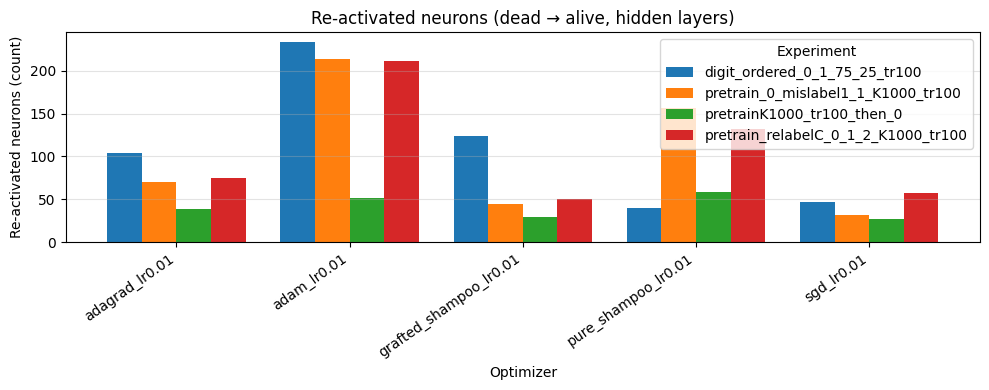

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)
plot_reactivated_neuron_counts_grouped(
    df_reactivated_multi,
    ax=ax,
    experiment_order=list(EXPERIMENT_RUNS.keys()),
    optimizer_order=OPTIMIZER_IDS,
	bar_width = bar_width
)
fig.tight_layout()
plt.show()